# **FINAL PROJECT** - Does AI Improve Customer Satisfaction?
## **Group 10**: Clément Guyot de La Pommeraye, Erik van der Sangen, Jacopo Cagnacci, Giacomo Bellodi​


## In this notebook we run the core analysis of our project, observing  the effects of AI implementations in cunsomer complaints.

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf


In [ ]:
# load data
full_data = pd.read_csv('full_data.csv')
len(full_data)

In [ ]:
len(full_data)

439847

## **Create deciles variables**

In [ ]:
import pandas as pd

def clean_numeric_columns(df, columns):

    for col in columns:
        # Skip columns that are missing
        if col not in df.columns:
            print(f"Warning: column '{col}' not found in dataframe, skipping.")
            continue

        # Only transform if dtype is object
        if df[col].dtype == 'O':   # object dtype
            df[col] = (
                df[col]
                .astype(str)
                .str.replace(',', '', regex=False)
            )
            df[col] = pd.to_numeric(df[col], errors='coerce')
        else:
            # Optional: notify that the column was skipped
            print(f"Column '{col}' already numeric, skipping.")

    return df



In [ ]:
cols_to_clean = [
    'NUMBER OF HOUSEHOLDS',
       'MEDIAN INCOME GENERAL', 'PERCENTAGE WHITE', 'MEDIAN INCOME WHITE',
       'PERCENTAGE BLACK', 'MEDIAN INCOME BLACK', 'PERCENTAGE NATIVE AMERICAN',
       'MEDIAN INCOME NATIVE AMERICAN', 'PERCENTAGE ASIAN',
       'MEDIAN INCOME ASIAN', 'PERCENTAGE HAWAIIAN', 'MEDIAN INCOME HAWAIIAN',
       'PERCENTAGE OTHER RACE', 'MEDIAN INCOME OTHER RACE',
       'PERCENTAGE 2 OR MORE RACES', 'MEDIAN INCOME 2 OR MORE RACES',
       'PERCENTAGE HISPANIC/LATINO ORIGIN (OF ANY RACE)',
       'MEDIAN INCOME HISPANIC/LATINO ORIGIN (OF ANY RACE)',
       'PERCENTAGE WHITE ALONE NOT HISPANIC',
       'MEDIAN INCOME WHITE ALONE NOT HISPANIC',
       'PERCENTAGE HOUSEHOLDER 15-24 YO', 'MEDIAN INCOME HOUSEHOLDER 15-24 YO',
       'PERCENTAGE HOUSEHOLDER 25-44 YO', 'MEDIAN INCOME HOUSEHOLDER 25-44 YO',
       'PERCENTAGE HOUSEHOLDER 45-64 YO', 'MEDIAN INCOME HOUSEHOLDER 45-64 YO',
       'PERCENTAGE HOUSEHOLDER 65+ YO', 'MEDIAN INCOME HOUSEHOLDER 65+ YO'
]

full_data = clean_numeric_columns(full_data, cols_to_clean)


Column 'NUMBER OF HOUSEHOLDS' already numeric, skipping.
Column 'PERCENTAGE WHITE' already numeric, skipping.
Column 'PERCENTAGE BLACK' already numeric, skipping.
Column 'PERCENTAGE NATIVE AMERICAN' already numeric, skipping.
Column 'PERCENTAGE ASIAN' already numeric, skipping.
Column 'PERCENTAGE HAWAIIAN' already numeric, skipping.
Column 'PERCENTAGE OTHER RACE' already numeric, skipping.
Column 'PERCENTAGE 2 OR MORE RACES' already numeric, skipping.
Column 'PERCENTAGE HISPANIC/LATINO ORIGIN (OF ANY RACE)' already numeric, skipping.
Column 'PERCENTAGE WHITE ALONE NOT HISPANIC' already numeric, skipping.
Column 'PERCENTAGE HOUSEHOLDER 15-24 YO' already numeric, skipping.
Column 'PERCENTAGE HOUSEHOLDER 25-44 YO' already numeric, skipping.
Column 'PERCENTAGE HOUSEHOLDER 45-64 YO' already numeric, skipping.
Column 'PERCENTAGE HOUSEHOLDER 65+ YO' already numeric, skipping.


In [ ]:
def add_deciles(df, columns, q=10, suffix='_decile'):

    for col in columns:
        if col not in df.columns:
            print(f"Warning: column '{col}' not found, skipping deciles.")
            continue

        df[col + suffix] = pd.qcut(
            df[col],
            q=q,
            labels=False,
            duplicates='drop'
        )
    return df


In [ ]:
full_data = add_deciles(full_data, cols_to_clean, q=10)

In [ ]:
full_data.columns

Index(['Unnamed: 0', 'Date received', 'Product', 'Sub-product', 'Issue',
       'Sub-issue', 'Consumer complaint narrative', 'Company public response',
       'Company', 'State', 'zip', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?', 'Consumer disputed?', 'Complaint ID', 'Year',
       'GEOGRAPHY', 'ZIP CODE', 'NUMBER OF HOUSEHOLDS',
       'MEDIAN INCOME GENERAL', 'PERCENTAGE WHITE', 'MEDIAN INCOME WHITE',
       'PERCENTAGE BLACK', 'MEDIAN INCOME BLACK', 'PERCENTAGE NATIVE AMERICAN',
       'MEDIAN INCOME NATIVE AMERICAN', 'PERCENTAGE ASIAN',
       'MEDIAN INCOME ASIAN', 'PERCENTAGE HAWAIIAN', 'MEDIAN INCOME HAWAIIAN',
       'PERCENTAGE OTHER RACE', 'MEDIAN INCOME OTHER RACE',
       'PERCENTAGE 2 OR MORE RACES', 'MEDIAN INCOME 2 OR MORE RACES',
       'PERCENTAGE HISPANIC/LATINO ORIGIN (OF ANY RACE)',
       'MEDIAN INCOME HISPANIC/LATINO ORIGIN (OF ANY RACE)',
       'PERCENTAGE WHITE

## **ANALYSIS WITHIN BANKS THAT STARTED ADOPTING AI (CHATBOTS)**

Subset only the banks that use AI (`AI_overall = 1`)




In [ ]:
banks_AIbot = full_data[full_data['AI_overall'] == 1]
print(f'We have now: {len(banks_AIbot)} complaints.')
print(f'We have now: {len(banks_AIbot['Company'].unique())} banks.')

We have now: 102753 complaints.
We have now: 53 banks.


In [ ]:
print(banks_AIbot['AI_dummy'].value_counts())

AI_dummy
1          63507
0          30539
Unknown     8707
Name: count, dtype: int64


In [ ]:
banks_AIbot['Year'].value_counts()

,count
Year,
2023,21644
2022,16369
2021,14834
2020,11626
2018,8935
2019,8595
2017,8299
2016,7477
2015,4974


In [ ]:
# Group by Year and AI_dummy and count complaints
ai_counts = (
    banks_AIbot
    .groupby(['Year', 'AI_dummy'])['Complaint ID']
    .count()
    .unstack(fill_value=0)      # columns = '0', '1', 'Unknown'
    .sort_index()
)

ai_counts

AI_dummy,0,1,Unknown
Year,,,
2015,4510,78,386
2016,6324,661,492
2017,5872,1685,742
2018,4148,3945,842
2019,2773,5217,605
2020,2652,7909,1065
2021,1969,11365,1500
2022,1956,12948,1465
2023,335,19699,1610


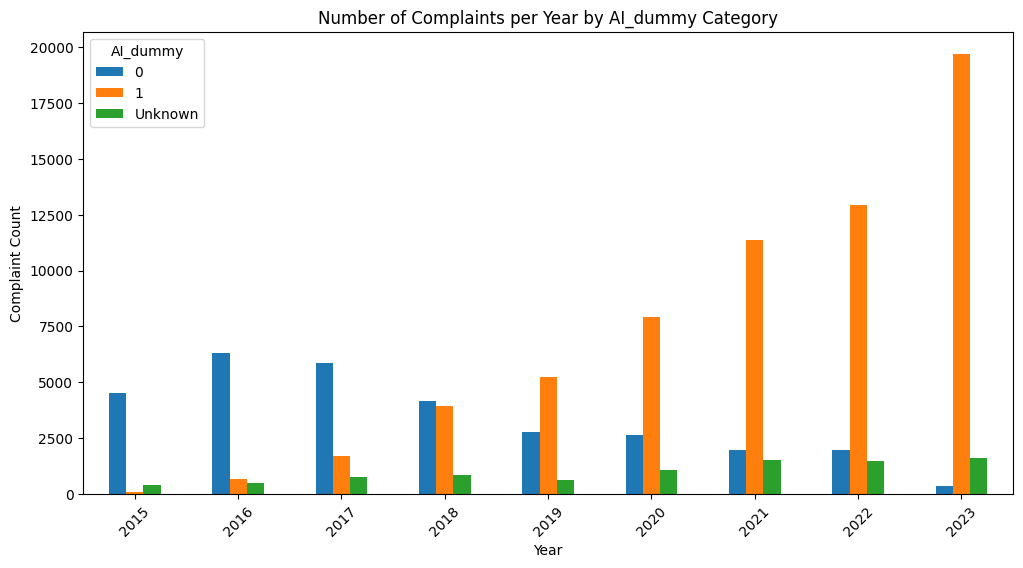

In [ ]:
import matplotlib.pyplot as plt

ai_counts.plot(kind='bar', figsize=(12,6))
plt.title("Number of Complaints per Year by AI_dummy Category")
plt.ylabel("Complaint Count")
plt.xlabel("Year")
plt.xticks(rotation=45)
plt.show()


Intuitively, AI complaints share increases sharply as time goes by since we are considering AI companies.

## **DIFFERENCE IN SENTIMENT SCORES**

          emo_final  tone_final  harm_final
AI_dummy                                   
0          3.538819    3.084941    2.192835
1          3.500024    3.071535    2.155117


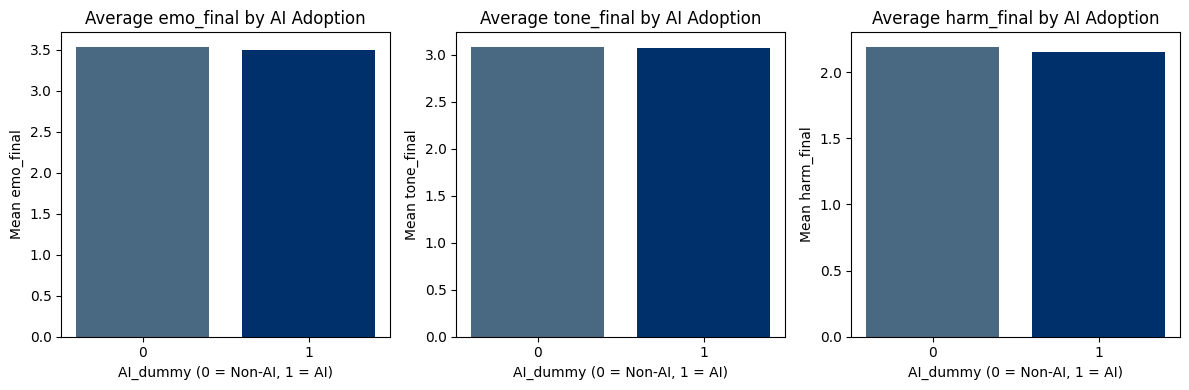

In [ ]:

# 1. Filter out 'Unknown' AI_dummy - we consider only banks for which we know the intro date.

df0 = banks_AIbot[banks_AIbot['AI_dummy'].isin(['0', '1'])].copy()
df0['AI_dummy'] = df0['AI_dummy'].astype(int)


# 2. Compute overall means by AI vs non-AI
mean_table = (
    df0.groupby('AI_dummy')[['emo_final', 'tone_final', 'harm_final']]
    .mean()
)

print(mean_table)

# 3. Plot: emo_final, tone_final, harm_final


sent_vars = ['emo_final', 'tone_final', 'harm_final']
colors = ['#496983', '#00306B']

plt.figure(figsize=(12,4))

for i, var in enumerate(sent_vars):
    plt.subplot(1, 3, i+1)
    plt.bar(
        mean_table.index.astype(str),
        mean_table[var],
        color=[colors[x] for x in mean_table.index]
    )
    plt.title(f"Average {var} by AI Adoption")
    plt.xlabel("AI_dummy (0 = Non-AI, 1 = AI)")
    plt.ylabel(f"Mean {var}")

plt.tight_layout()
plt.show()

There is basically no difference between the raw scores across the two groups. For this reason we introduce controls and we run regression models to capture a possible impact of AI.

## **MODEL 1:** Within-bank pre/post comparison


In [ ]:
# 1. Keep only rows with clear 0/1 AI_dummy
df1 = banks_AIbot[banks_AIbot['AI_dummy'].isin(['0', '1'])].copy()
df1['AI_dummy'] = df1['AI_dummy'].astype(int)

print("AI_dummy value counts in df1:")
print(df1['AI_dummy'].value_counts(dropna=False))

# 2. Helper to run the model for a given dependent variable
def run_model1(dep_var):
    cols_needed = [dep_var, 'AI_dummy', 'Company']
    d = df1[cols_needed].dropna().copy()
    formula = f'{dep_var} ~ AI_dummy + C(Company)'
    model = smf.ols(formula, data=d).fit(
        cov_type="cluster",
        cov_kwds={"groups": d["Company"]}  # cluster SEs by bank
    )
    print(f"\n=== MODEL 1: {dep_var} ~ AI_dummy + C(Company) ===")
    print(model.summary())
    return model

AI_dummy value counts in df1:
AI_dummy
1    63507
0    30539
Name: count, dtype: int64


In [ ]:
m1_emo  = run_model1('emo_final')


=== MODEL 1: emo_final ~ AI_dummy + C(Company) ===
                            OLS Regression Results                            
Dep. Variable:              emo_final   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     18.95
Date:                Tue, 02 Dec 2025   Prob (F-statistic):           9.38e-05
Time:                        10:07:34   Log-Likelihood:            -1.0155e+05
No. Observations:               94046   AIC:                         2.032e+05
Df Residuals:                   94005   BIC:                         2.036e+05
Df Model:                          40                                         
Covariance Type:              cluster                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 40, but rank is 1
  warnings.warn('covariance of constraints does not have full '


When we compare each bank to itself, before vs after the introduction of AI chatbots, the average anger level of complaints (emo_final) does not change in a meaningful way. The model is too simple and noisy.

In [ ]:
m1_tone = run_model1('tone_final')



=== MODEL 1: tone_final ~ AI_dummy + C(Company) ===
                            OLS Regression Results                            
Dep. Variable:             tone_final   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     7.370
Date:                Tue, 02 Dec 2025   Prob (F-statistic):            0.00983
Time:                        10:07:36   Log-Likelihood:                -79751.
No. Observations:               94046   AIC:                         1.596e+05
Df Residuals:                   94005   BIC:                         1.600e+05
Df Model:                          40                                         
Covariance Type:              cluster                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 40, but rank is 1
  warnings.warn('covariance of constraints does not have full '


In [ ]:
m1_harm = run_model1('harm_final')


=== MODEL 1: harm_final ~ AI_dummy + C(Company) ===
                            OLS Regression Results                            
Dep. Variable:             harm_final   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     22.98
Date:                Tue, 02 Dec 2025   Prob (F-statistic):           2.39e-05
Time:                        10:07:37   Log-Likelihood:                -88753.
No. Observations:               94046   AIC:                         1.776e+05
Df Residuals:                   94005   BIC:                         1.780e+05
Df Model:                          40                                         
Covariance Type:              cluster                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 40, but rank is 1
  warnings.warn('covariance of constraints does not have full '


## **MODEL 2**: Incorporating time fixed effects (controlling per month&year)



In [ ]:
# 1. Filter dataset: only 0/1 AI_dummy
banks_AIbot['Date received'] = pd.to_datetime(banks_AIbot['Date received'])
df2 = banks_AIbot[banks_AIbot['AI_dummy'].isin(['0','1'])].copy()
df2['AI_dummy'] = df2['AI_dummy'].astype(int)

# 2. Create a YearMonth variable if not present
df2['YearMonth'] = df2['Date received'].dt.to_period("M").astype(str)

# Helper function to run Model 2 for any variable
def run_model2(dep):
    cols_needed = [dep, 'AI_dummy', 'Company', 'YearMonth']
    d = df2[cols_needed].dropna().copy()

    formula = f"{dep} ~ AI_dummy + C(Company) + C(YearMonth)"

    model = smf.ols(formula, data=d).fit(
        cov_type="cluster",
        cov_kwds={"groups": d["Company"]}   # cluster by bank
    )

    print(f"\n=== MODEL 2: {dep} ~ AI_dummy + C(Company) + C(YearMonth) ===")
    print(model.summary())
    return model


/tmp/ipython-input-168545459.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  banks_AIbot['Date received'] = pd.to_datetime(banks_AIbot['Date received'])


In [ ]:
m2_emo  = run_model2('emo_final')


=== MODEL 2: emo_final ~ AI_dummy + C(Company) + C(YearMonth) ===
                            OLS Regression Results                            
Dep. Variable:              emo_final   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                 2.557e+11
Date:                Tue, 02 Dec 2025   Prob (F-statistic):          1.24e-212
Time:                        10:07:42   Log-Likelihood:            -1.0142e+05
No. Observations:               94046   AIC:                         2.031e+05
Df Residuals:                   93900   BIC:                         2.045e+05
Df Model:                         145                                         
Covariance Type:              cluster                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 145, but rank is 39
  warnings.warn('covariance of constraints does not have full '


In [ ]:
m2_tone = run_model2('tone_final')


=== MODEL 2: tone_final ~ AI_dummy + C(Company) + C(YearMonth) ===
                            OLS Regression Results                            
Dep. Variable:             tone_final   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                -1.359e+10
Date:                Tue, 02 Dec 2025   Prob (F-statistic):               1.00
Time:                        10:07:48   Log-Likelihood:                -79647.
No. Observations:               94046   AIC:                         1.596e+05
Df Residuals:                   93900   BIC:                         1.610e+05
Df Model:                         145                                         
Covariance Type:              cluster                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 145, but rank is 39
  warnings.warn('covariance of constraints does not have full '


In [ ]:
m2_harm = run_model2('harm_final')


=== MODEL 2: harm_final ~ AI_dummy + C(Company) + C(YearMonth) ===
                            OLS Regression Results                            
Dep. Variable:             harm_final   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                -3.501e+11
Date:                Tue, 02 Dec 2025   Prob (F-statistic):               1.00
Time:                        10:07:54   Log-Likelihood:                -88633.
No. Observations:               94046   AIC:                         1.776e+05
Df Residuals:                   93900   BIC:                         1.789e+05
Df Model:                         145                                         
Covariance Type:              cluster                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 145, but rank is 39
  warnings.warn('covariance of constraints does not have full '


On average, across all ZIP codes, products, and banks that adopted AI, the emotional intensity of consumer complaints did not change.
Now we observe if the effect differ when observe some kind of subgroups in the population.

## **MODEL 3a**: Income Heterogeneity (with income deciles)

In [ ]:
# 1. Filter only rows with AI_dummy 0/1
df3 = banks_AIbot[banks_AIbot['AI_dummy'].isin(['0','1'])].copy()
df3['AI_dummy'] = df3['AI_dummy'].astype(int)

# 2. Create YearMonth FE if not present
df3['YearMonth'] = df3['Date received'].dt.to_period("M").astype(str)

# 3. Make sure income decile is numeric categorical
df3['income_dec'] = pd.to_numeric(df3['MEDIAN INCOME GENERAL_decile'], errors='coerce')
df3['income_dec'] = df3['income_dec'].astype('category')

# 4. Helper function to run the model
def run_model3(dep):
    cols_needed = [dep, 'AI_dummy', 'income_dec', 'Company', 'YearMonth']
    d = df3[cols_needed].dropna().copy()

    formula = f"{dep} ~ AI_dummy * income_dec + C(Company) + C(YearMonth)"

    model = smf.ols(formula, data=d).fit(
        cov_type="cluster",
        cov_kwds={"groups": d["Company"]}  # cluster by bank
    )

    print(f"\n=== MODEL 3 (Income Heterogeneity): {dep} ===")
    print(model.summary())
    return model

In [ ]:
# 5. Run the model for all 3 outcomes
m3_emo  = run_model3("emo_final")


=== MODEL 3 (Income Heterogeneity): emo_final ===
                            OLS Regression Results                            
Dep. Variable:              emo_final   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                 3.110e+11
Date:                Tue, 02 Dec 2025   Prob (F-statistic):          2.72e-214
Time:                        10:08:05   Log-Likelihood:            -1.0132e+05
No. Observations:               93992   AIC:                         2.030e+05
Df Residuals:                   93828   BIC:                         2.045e+05
Df Model:                         163                                         
Covariance Type:              cluster                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 163, but rank is 39
  warnings.warn('covariance of constraints does not have full '


In ZIP codes with higher household income, complaints become slightly more emotionally intense after banks implement AI chatbots. Significant results for the interactions AI_dummy x income decile 7,8,9.
This result makes sense as grater the income, more complex should be the complaints the file as the 'have more at stake'. Chatbots are usually very efficient for easy tasks, but when the topic of discussion gets more complex then their results may be worse and the effect on the user is more frustration (higher emotion score).

/tmp/ipython-input-326341541.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['income_dec', 'AI_dummy'])['emo_final']


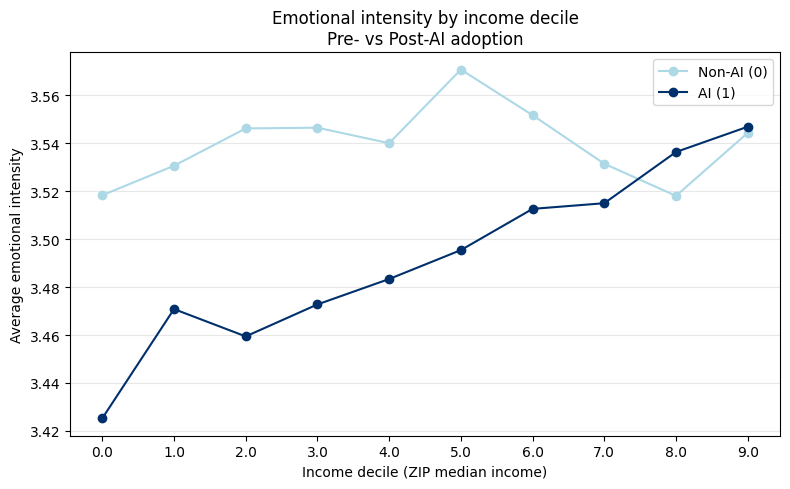

In [ ]:
# 1. Compute mean emo_final by income_dec × AI_dummy
emo_by_inc = (
    df3
    .groupby(['income_dec', 'AI_dummy'])['emo_final']
    .mean()
    .reset_index()
)

# Ensure income_dec is numeric and sorted
emo_by_inc['income_dec'] = pd.to_numeric(emo_by_inc['income_dec'], errors='coerce')
emo_by_inc = emo_by_inc.sort_values('income_dec')

# 2. Split into pre-AI (0) and post-AI (1)
pre = emo_by_inc[emo_by_inc['AI_dummy'] == 0]
post = emo_by_inc[emo_by_inc['AI_dummy'] == 1]

# 3. Plot
plt.figure(figsize=(8,5))

plt.plot(
    pre['income_dec'],
    pre['emo_final'],
    marker='o',
    linestyle='-',
    color='lightblue',
    label='Non-AI (0)'
)

plt.plot(
    post['income_dec'],
    post['emo_final'],
    marker='o',
    linestyle='-',
    color='#00306B',
    label='AI (1)'
)

plt.xticks(ticks=sorted(df3['income_dec'].dropna().unique()), labels=sorted(df3['income_dec'].dropna().unique()))
plt.xlabel('Income decile (ZIP median income)')
plt.ylabel('Average emotional intensity')
plt.title('Emotional intensity by income decile\nPre- vs Post-AI adoption')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
m3_tone = run_model3("tone_final")


=== MODEL 3 (Income Heterogeneity): tone_final ===
                            OLS Regression Results                            
Dep. Variable:             tone_final   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                 1.712e+09
Date:                Tue, 02 Dec 2025   Prob (F-statistic):          3.07e-170
Time:                        10:08:13   Log-Likelihood:                -79583.
No. Observations:               93992   AIC:                         1.595e+05
Df Residuals:                   93828   BIC:                         1.610e+05
Df Model:                         163                                         
Covariance Type:              cluster                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 163, but rank is 39
  warnings.warn('covariance of constraints does not have full '


/tmp/ipython-input-4179721137.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['income_dec', 'AI_dummy'])['tone_final']


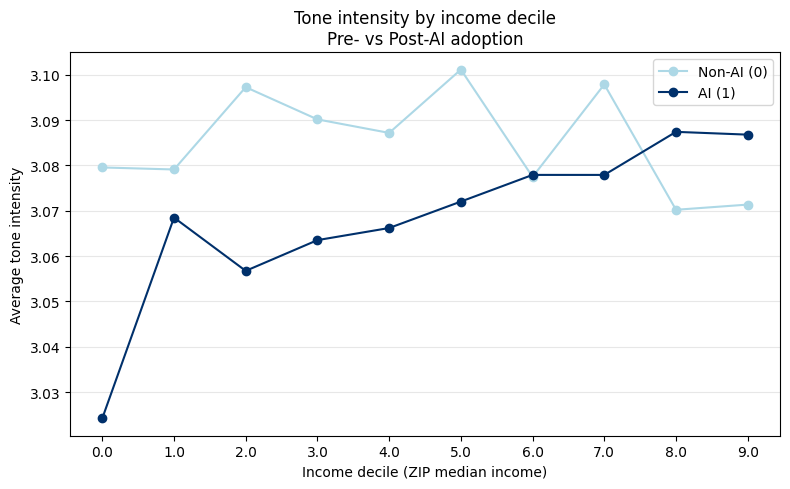

In [ ]:
# 1. Compute mean tone_final by income_dec × AI_dummy
tone_by_inc = (
    df3
    .groupby(['income_dec', 'AI_dummy'])['tone_final']
    .mean()
    .reset_index()
)

# Ensure income_dec is numeric and sorted
tone_by_inc['income_dec'] = pd.to_numeric(tone_by_inc['income_dec'], errors='coerce')
tone_by_inc = tone_by_inc.sort_values('income_dec')

# 2. Split into pre-AI (0) and post-AI (1)
pre = tone_by_inc[tone_by_inc['AI_dummy'] == 0]
post = tone_by_inc[tone_by_inc['AI_dummy'] == 1]

# 3. Plot
plt.figure(figsize=(8,5))

plt.plot(
    pre['income_dec'],
    pre['tone_final'],
    marker='o',
    linestyle='-',
    color='lightblue',
    label='Non-AI (0)'
)

plt.plot(
    post['income_dec'],
    post['tone_final'],
    marker='o',
    linestyle='-',
    color='#00306B',
    label='AI (1)'
)

plt.xticks(ticks=sorted(df3['income_dec'].dropna().unique()), labels=sorted(df3['income_dec'].dropna().unique()))
plt.xlabel('Income decile (ZIP median income)')
plt.ylabel('Average tone intensity')
plt.title('Tone intensity by income decile\nPre- vs Post-AI adoption')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In the tone model, the baseline effect of AI adoption is a significant reduction in tone (β = −0.037, p < 0.05), indicating that in lower-income ZIP codes, complaints become less hostile following chatbot implementation.

However, the AI × income interaction terms show that this effect reverses in the upper income deciles. ZIP codes in deciles 6, 8, and 9 exhibit statistically significant increases in tone following AI adoption. The combined effects for these groups range from +0.016 to +0.034 on the 1–5 tone scale.

In [ ]:
m3_harm = run_model3("harm_final")


=== MODEL 3 (Income Heterogeneity): harm_final ===


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 163, but rank is 39
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:             harm_final   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                 3.793e+11
Date:                Tue, 02 Dec 2025   Prob (F-statistic):          5.66e-216
Time:                        10:08:19   Log-Likelihood:                -88559.
No. Observations:               93992   AIC:                         1.774e+05
Df Residuals:                   93828   BIC:                         1.790e+05
Df Model:                         163                                         
Covariance Type:              cluster                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------

/tmp/ipython-input-3303542439.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['income_dec', 'AI_dummy'])['harm_final']


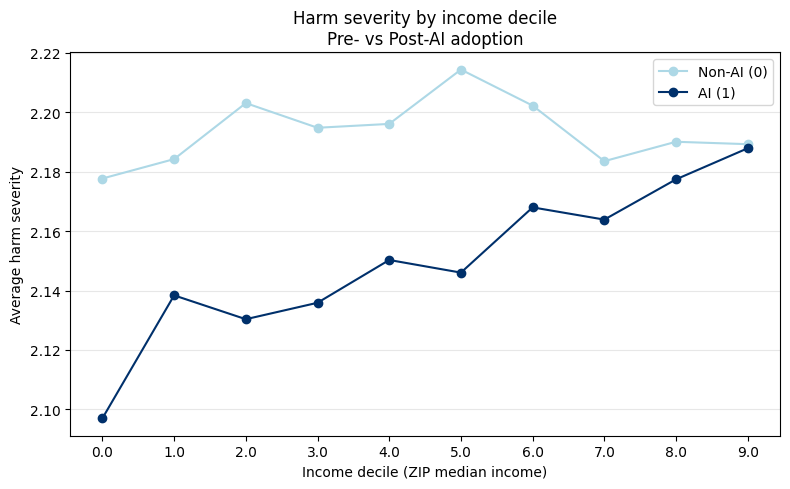

In [ ]:
# 1. Compute mean harm_fina by income_dec × AI_dummy
harm_by_inc = (
    df3
    .groupby(['income_dec', 'AI_dummy'])['harm_final']
    .mean()
    .reset_index()
)

# Ensure income_dec is numeric and sorted
harm_by_inc['income_dec'] = pd.to_numeric(harm_by_inc['income_dec'], errors='coerce')
harm_by_inc = harm_by_inc.sort_values('income_dec')

# 2. Split into pre-AI (0) and post-AI (1)
pre = harm_by_inc[harm_by_inc['AI_dummy'] == 0]
post = harm_by_inc[harm_by_inc['AI_dummy'] == 1]

# 3. Plot
plt.figure(figsize=(8,5))

plt.plot(
    pre['income_dec'],
    pre['harm_final'],
    marker='o',
    linestyle='-',
    color='lightblue',
    label='Non-AI (0)'
)

plt.plot(
    post['income_dec'],
    post['harm_final'],
    marker='o',
    linestyle='-',
    color='#00306B',
    label='AI (1)'
)

plt.xticks(ticks=sorted(df3['income_dec'].dropna().unique()), labels=sorted(df3['income_dec'].dropna().unique()))
plt.xlabel('Income decile (ZIP median income)')
plt.ylabel('Average harm severity')
plt.title('Harm severity by income decile\nPre- vs Post-AI adoption')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
banks_AIbot[['emo_final', 'tone_final', 'harm_final']].corr()

,emo_final,tone_final,harm_final
emo_final,1.000000,0.720663,0.756077
tone_final,0.720663,1.000000,0.645193
harm_final,0.756077,0.645193,1.000000


<Figure size 1400x700 with 0 Axes>

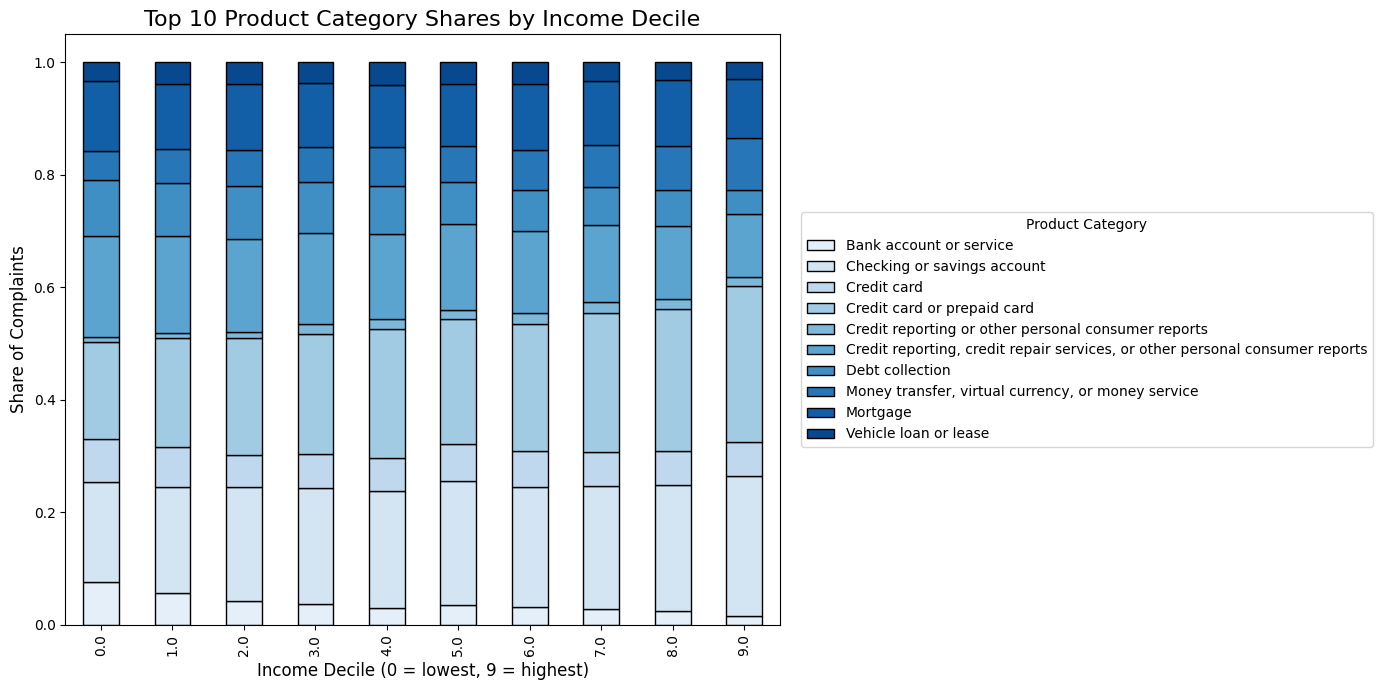

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Prepare income decile and data

df = banks_AIbot.copy()

df['income_dec'] = pd.to_numeric(df['MEDIAN INCOME GENERAL_decile'], errors='coerce')
df_clean = df.dropna(subset=['income_dec', 'Product']).copy()

# 2. Identify the Top 10 most common product categories
top10_products = (
    df_clean['Product']
    .value_counts()
    .head(10)
    .index
)

df_top10 = df_clean[df_clean['Product'].isin(top10_products)].copy()


# 3. Compute % shares per income decile × product

counts = (
    df_top10.groupby(['income_dec', 'Product'])['Complaint ID']
    .count()
    .reset_index(name='count')
)

total_by_decile = counts.groupby('income_dec')['count'].transform('sum')
counts['share'] = counts['count'] / total_by_decile

share_pivot = counts.pivot(index='income_dec', columns='Product', values='share').fillna(0)


# 4. Plot with blue/dark color palette

palette = sns.color_palette("Blues", n_colors=len(top10_products))

plt.figure(figsize=(14, 7))

share_pivot.plot(
    kind='bar',
    stacked=True,
    color=sns.color_palette(palette, as_cmap=False),
    figsize=(14, 7),
    edgecolor="black"
)

plt.title("Top 10 Product Category Shares by Income Decile", fontsize=16)
plt.xlabel("Income Decile (0 = lowest, 9 = highest)", fontsize=12)
plt.ylabel("Share of Complaints", fontsize=12)
plt.legend(
    title="Product Category",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left"
)
plt.tight_layout()
plt.show()


<Figure size 1400x700 with 0 Axes>

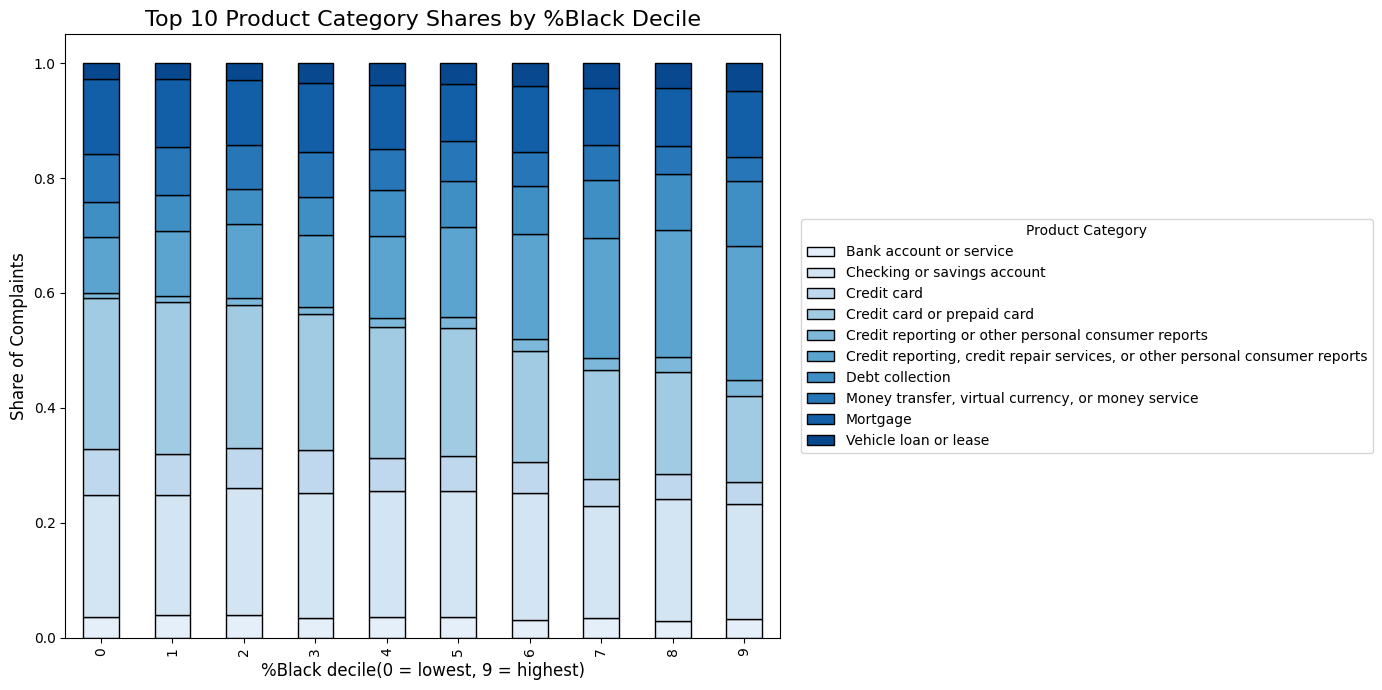

In [ ]:
# 1. Prepare income decile and data

df = banks_AIbot.copy()

df['pct_black'] = pd.to_numeric(df['PERCENTAGE BLACK_decile'], errors='coerce')
df_clean = df.dropna(subset=['pct_black', 'Product']).copy()


# 2. Identify the Top 10 most common product categories

top10_products = (
    df_clean['Product']
    .value_counts()
    .head(10)
    .index
)

df_top10 = df_clean[df_clean['Product'].isin(top10_products)].copy()


# 3. Compute % shares per income decile × product

counts = (
    df_top10.groupby(['pct_black', 'Product'])['Complaint ID']
    .count()
    .reset_index(name='count')
)

total_by_decile = counts.groupby('pct_black')['count'].transform('sum')
counts['share'] = counts['count'] / total_by_decile

share_pivot = counts.pivot(index='pct_black', columns='Product', values='share').fillna(0)




palette = sns.color_palette("Blues", n_colors=len(top10_products))

plt.figure(figsize=(14, 7))

share_pivot.plot(
    kind='bar',
    stacked=True,
    color=sns.color_palette(palette, as_cmap=False),
    figsize=(14, 7),
    edgecolor="black"
)

plt.title("Top 10 Product Category Shares by %Black Decile", fontsize=16)
plt.xlabel("%Black decile(0 = lowest, 9 = highest)", fontsize=12)
plt.ylabel("Share of Complaints", fontsize=12)
plt.legend(
    title="Product Category",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left"
)
plt.tight_layout()
plt.show()


## **MODEL 3b**: Income Heterogeneity (with income variable only)

In [ ]:
df_inc = banks_AIbot[banks_AIbot['AI_dummy'].isin(['0','1'])].copy()
df_inc['AI_dummy'] = df_inc['AI_dummy'].astype(int)

# Make sure Date received is datetime
df_inc['YearMonth'] = df_inc['Date received'].dt.to_period("M").astype(str)

# Ensure income is numeric
df_inc['median_income'] = pd.to_numeric(
    df_inc['MEDIAN INCOME GENERAL'], errors='coerce'
)

# Drop missing entries
df_inc = df_inc.dropna(subset=['median_income', 'emo_final', 'tone_final', 'harm_final'])


In [ ]:
def run_income_continuous(dep):
    formula = f"{dep} ~ AI_dummy * median_income + C(Company) + C(YearMonth)"
    model = smf.ols(formula, data=df_inc).fit(
        cov_type='cluster',
        cov_kwds={'groups': df_inc['Company']}
    )
    print(f"\n=== MODEL 3b (Continuous Income): {dep} ===")
    print(model.summary())
    return model

In [ ]:
m_inc_emo  = run_income_continuous('emo_final')
m_inc_tone = run_income_continuous('tone_final')
m_inc_harm = run_income_continuous('harm_final')


=== MODEL 3b (Continuous Income): emo_final ===
                            OLS Regression Results                            
Dep. Variable:              emo_final   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                 6.107e+11
Date:                Tue, 02 Dec 2025   Prob (F-statistic):          5.24e-220
Time:                        10:08:24   Log-Likelihood:            -1.0133e+05
No. Observations:               93992   AIC:                         2.030e+05
Df Residuals:                   93844   BIC:                         2.044e+05
Df Model:                         147                                         
Covariance Type:              cluster                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 147, but rank is 39
  warnings.warn('covariance of constraints does not have full '



=== MODEL 3b (Continuous Income): tone_final ===
                            OLS Regression Results                            
Dep. Variable:             tone_final   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                -1.987e+09
Date:                Tue, 02 Dec 2025   Prob (F-statistic):               1.00
Time:                        10:08:30   Log-Likelihood:                -79594.
No. Observations:               93992   AIC:                         1.595e+05
Df Residuals:                   93844   BIC:                         1.609e+05
Df Model:                         147                                         
Covariance Type:              cluster                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 147, but rank is 39
  warnings.warn('covariance of constraints does not have full '



=== MODEL 3b (Continuous Income): harm_final ===
                            OLS Regression Results                            
Dep. Variable:             harm_final   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                -2.765e+11
Date:                Tue, 02 Dec 2025   Prob (F-statistic):               1.00
Time:                        10:08:35   Log-Likelihood:                -88570.
No. Observations:               93992   AIC:                         1.774e+05
Df Residuals:                   93844   BIC:                         1.788e+05
Df Model:                         147                                         
Covariance Type:              cluster                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 147, but rank is 39
  warnings.warn('covariance of constraints does not have full '


This confirms the decile analysis: as income increases, sentiment (frustration)increases.

## **HETEROGENEITY ACROSS %RACES IN THE POPULATION**

## **Model 4a**: %Black

In [ ]:
# Filter usable rows
df_R1 = banks_AIbot[banks_AIbot['AI_dummy'].isin(['0','1'])].copy()
df_R1['AI_dummy'] = df_R1['AI_dummy'].astype(int)

# Create YearMonth if not present
df_R1['YearMonth'] = df_R1['Date received'].dt.to_period("M").astype(str)

# Ensure pct_black is numeric
df_R1['pct_black'] = pd.to_numeric(df_R1['PERCENTAGE BLACK'], errors='coerce')

# Convert to proportion if necessary (0–1 scale)
if df_R1['pct_black'].max() > 1:
    df_R1['pct_black'] = df_R1['pct_black'] / 100

# Drop missing values in key variables
df_R1 = df_R1.dropna(subset=['emo_final', 'pct_black'])

In [ ]:
def run_R1(dep):
    formula = f"{dep} ~ AI_dummy * pct_black + C(Company) + C(YearMonth)"
    model = smf.ols(formula, data=df_R1).fit(
        cov_type='cluster',
        cov_kwds={'groups': df_R1['Company']}
    )
    print(f"\n=== MODEL R1: {dep} ~ AI_dummy * pct_black ===")
    print(model.summary())
    return model

mR1_emo  = run_R1('emo_final')



=== MODEL R1: emo_final ~ AI_dummy * pct_black ===
                            OLS Regression Results                            
Dep. Variable:              emo_final   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                 4.626e+11
Date:                Tue, 02 Dec 2025   Prob (F-statistic):          1.18e-217
Time:                        10:08:40   Log-Likelihood:            -1.0133e+05
No. Observations:               94046   AIC:                         2.030e+05
Df Residuals:                   93898   BIC:                         2.044e+05
Df Model:                         147                                         
Covariance Type:              cluster                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 147, but rank is 39
  warnings.warn('covariance of constraints does not have full '


As the Black population share increases, the effect of AI adoption becomes more negative — meaning complaints become less emotionally intense in high-% Black ZIPs after AI adoption.

In [ ]:
mR1_tone  = run_R1('tone_final')


=== MODEL R1: tone_final ~ AI_dummy * pct_black ===
                            OLS Regression Results                            
Dep. Variable:             tone_final   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                -2.087e+10
Date:                Tue, 02 Dec 2025   Prob (F-statistic):               1.00
Time:                        10:08:46   Log-Likelihood:                -79591.
No. Observations:               94046   AIC:                         1.595e+05
Df Residuals:                   93898   BIC:                         1.609e+05
Df Model:                         147                                         
Covariance Type:              cluster                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 147, but rank is 39
  warnings.warn('covariance of constraints does not have full '


In [ ]:
mR1_harm  = run_R1('harm_final')


=== MODEL R1: harm_final ~ AI_dummy * pct_black ===
                            OLS Regression Results                            
Dep. Variable:             harm_final   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                 6.208e+10
Date:                Tue, 02 Dec 2025   Prob (F-statistic):          1.20e-200
Time:                        10:08:51   Log-Likelihood:                -88586.
No. Observations:               94046   AIC:                         1.775e+05
Df Residuals:                   93898   BIC:                         1.789e+05
Df Model:                         147                                         
Covariance Type:              cluster                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 147, but rank is 39
  warnings.warn('covariance of constraints does not have full '


## **Model 4b**: %hispanic

In [ ]:
# Ensure %Hispanic is numeric and in 0–1 scale
df_Rhis = banks_AIbot[banks_AIbot['AI_dummy'].isin(['0','1'])].copy()
df_Rhis['AI_dummy'] = df_Rhis['AI_dummy'].astype(int)
df_Rhis['YearMonth'] = df_Rhis['Date received'].dt.to_period("M").astype(str)

df_Rhis['pct_hispanic'] = pd.to_numeric(df_Rhis['PERCENTAGE HISPANIC/LATINO ORIGIN (OF ANY RACE)'], errors='coerce')
if df_Rhis['pct_hispanic'].max() > 1:
    df_Rhis['pct_hispanic'] = df_Rhis['pct_hispanic'] / 100

# Drop missing rows
df_Rhis = df_Rhis.dropna(subset=['pct_hispanic', 'emo_final', 'tone_final', 'harm_final'])

# Run model function
import statsmodels.formula.api as smf

def run_R2A(dep):
    print(f"\n=== MODEL R2A: {dep} ~ AI_dummy * pct_hispanic ===")
    formula = f"{dep} ~ AI_dummy * pct_hispanic + C(Company) + C(YearMonth)"
    model = smf.ols(formula, data=df_Rhis).fit(
        cov_type='cluster',
        cov_kwds={'groups': df_Rhis['Company']}
    )
    print(model.summary())
    return model


In [ ]:
mR2A_emo  = run_R2A('emo_final')
mR2A_tone = run_R2A('tone_final')
mR2A_harm = run_R2A('harm_final')



=== MODEL R2A: emo_final ~ AI_dummy * pct_hispanic ===


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 147, but rank is 39
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:              emo_final   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                -2.515e+11
Date:                Tue, 02 Dec 2025   Prob (F-statistic):               1.00
Time:                        10:08:57   Log-Likelihood:            -1.0141e+05
No. Observations:               94046   AIC:                         2.031e+05
Df Residuals:                   93898   BIC:                         2.045e+05
Df Model:                         147                                         
Covariance Type:              cluster                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 147, but rank is 39
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:             tone_final   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                -7.816e+10
Date:                Tue, 02 Dec 2025   Prob (F-statistic):               1.00
Time:                        10:09:01   Log-Likelihood:                -79646.
No. Observations:               94046   AIC:                         1.596e+05
Df Residuals:                   93898   BIC:                         1.610e+05
Df Model:                         147                                         
Covariance Type:              cluster                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 147, but rank is 39
  warnings.warn('covariance of constraints does not have full '


HISPANIC NO SIGNIFICANT DIFFERENCES

## Model 4c: %asian

In [ ]:
# Ensure %Asian is numeric + proportion
df_Rasi = banks_AIbot[banks_AIbot['AI_dummy'].isin(['0','1'])].copy()
df_Rasi['AI_dummy'] = df_Rasi['AI_dummy'].astype(int)
df_Rasi['YearMonth'] = df_Rasi['Date received'].dt.to_period("M").astype(str)

df_Rasi['pct_asian'] = pd.to_numeric(df_Rasi['PERCENTAGE ASIAN'], errors='coerce')
if df_Rasi['pct_asian'].max() > 1:
    df_Rasi['pct_asian'] = df_Rasi['pct_asian'] / 100

df_Rasi = df_Rasi.dropna(subset=['pct_asian', 'emo_final', 'tone_final', 'harm_final'])

# Run model
def run_R2B(dep):
    print(f"\n=== MODEL R2B: {dep} ~ AI_dummy * pct_asian ===")
    formula = f"{dep} ~ AI_dummy * pct_asian + C(Company) + C(YearMonth)"
    model = smf.ols(formula, data=df_Rasi).fit(
        cov_type='cluster',
        cov_kwds={'groups': df_Rasi['Company']}
    )
    print(model.summary())
    return model

mR2B_emo  = run_R2B('emo_final')
mR2B_tone = run_R2B('tone_final')
mR2B_harm = run_R2B('harm_final')



=== MODEL R2B: emo_final ~ AI_dummy * pct_asian ===


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 147, but rank is 39
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:              emo_final   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                -2.061e+11
Date:                Tue, 02 Dec 2025   Prob (F-statistic):               1.00
Time:                        10:09:12   Log-Likelihood:            -1.0141e+05
No. Observations:               94046   AIC:                         2.031e+05
Df Residuals:                   93898   BIC:                         2.045e+05
Df Model:                         147                                         
Covariance Type:              cluster                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 147, but rank is 39
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:             tone_final   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                 7.772e+10
Date:                Tue, 02 Dec 2025   Prob (F-statistic):          1.50e-202
Time:                        10:09:17   Log-Likelihood:                -79645.
No. Observations:               94046   AIC:                         1.596e+05
Df Residuals:                   93898   BIC:                         1.610e+05
Df Model:                         147                                         
Covariance Type:              cluster                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 147, but rank is 39
  warnings.warn('covariance of constraints does not have full '


ASIAN OPPOSITE AS BLACK, coefficient is positive and significant.

## **Model 5:** Multi racial model

In [ ]:
import pandas as pd
import statsmodels.formula.api as smf

# Filter dataset for usable observations
df_R3 = banks_AIbot[banks_AIbot['AI_dummy'].isin(['0','1'])].copy()
df_R3['AI_dummy'] = df_R3['AI_dummy'].astype(int)
df_R3['Date received'] = pd.to_datetime(df_R3['Date received'])
df_R3['YearMonth'] = df_R3['Date received'].dt.to_period("M").astype(str)

# Convert race percentages to numeric and 0-1 scale
df_R3['pct_white']    = pd.to_numeric(df_R3['PERCENTAGE WHITE'], errors='coerce')
df_R3['pct_black']     = pd.to_numeric(df_R3['PERCENTAGE BLACK'], errors='coerce')
df_R3['pct_hispanic']  = pd.to_numeric(df_R3['PERCENTAGE HISPANIC/LATINO ORIGIN (OF ANY RACE)'], errors='coerce')
df_R3['pct_asian']     = pd.to_numeric(df_R3['PERCENTAGE ASIAN'], errors='coerce')

if df_R3['pct_black'].max() > 1:     df_R3['pct_black'] /= 100
if df_R3['pct_hispanic'].max() > 1:  df_R3['pct_hispanic'] /= 100
if df_R3['pct_asian'].max() > 1:     df_R3['pct_asian'] /= 100

# Drop missing data needed for model
df_R3 = df_R3.dropna(subset=[
    'emo_final','tone_final','harm_final',
    'pct_black','pct_hispanic','pct_asian'
])


In [ ]:
def run_multirace(dep):
    print(f"\n=== MODEL R3 (Multi-Race): {dep} ===")
    formula = (
        f"{dep} ~ AI_dummy"
        f" + pct_black + pct_hispanic + pct_asian"
        f" + AI_dummy*pct_black"
        f" + AI_dummy*pct_hispanic"
        f" + AI_dummy*pct_asian"
        f" + C(Company) + C(YearMonth)"
    )

    model = smf.ols(formula, data=df_R3).fit(
        cov_type='cluster',
        cov_kwds={'groups': df_R3['Company']}
    )

    print(model.summary())
    return model


In [ ]:
mR3_emo  = run_multirace("emo_final")
mR3_tone = run_multirace("tone_final")
mR3_harm = run_multirace("harm_final")



=== MODEL R3 (Multi-Race): emo_final ===


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 151, but rank is 39
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:              emo_final   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                -1.071e+12
Date:                Tue, 02 Dec 2025   Prob (F-statistic):               1.00
Time:                        23:40:50   Log-Likelihood:            -1.0132e+05
No. Observations:               94046   AIC:                         2.030e+05
Df Residuals:                   93894   BIC:                         2.044e+05
Df Model:                         151                                         
Covariance Type:              cluster                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 151, but rank is 39
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:             tone_final   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                -1.529e+11
Date:                Tue, 02 Dec 2025   Prob (F-statistic):               1.00
Time:                        23:40:57   Log-Likelihood:                -79587.
No. Observations:               94046   AIC:                         1.595e+05
Df Residuals:                   93894   BIC:                         1.609e+05
Df Model:                         151                                         
Covariance Type:              cluster                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 151, but rank is 39
  warnings.warn('covariance of constraints does not have full '


When all major ZIP-code racial composition measures are included simultaneously, the interaction between AI adoption and the Black population share remains large and statistically significant (β = –0.136, p < 0.001). This indicates that the reduction in emotional intensity associated with AI adoption is concentrated in ZIP codes with higher proportions of Black residents.

By contrast, the interaction with Hispanic share is small and statistically insignificant, and the interaction with Asian share becomes marginally significant only in the bivariate model but loses significance when included jointly with other groups.

These results suggest that the racial heterogeneity pattern is driven primarily by Black population share.

## **Model 5:** Diversity model (with diversity variable)

In [ ]:
df_div = banks_AIbot[banks_AIbot['AI_dummy'].isin(['0','1'])].copy()
df_div['AI_dummy'] = df_div['AI_dummy'].astype(int)

df_div['YearMonth'] = df_div['Date received'].dt.to_period("M").astype(str)

# Convert key race shares to numeric proportions
def make_prop(col):
    x = pd.to_numeric(df_div[col], errors='coerce')
    return x/100 if x.max() > 1 else x

df_div['pct_white']    = make_prop('PERCENTAGE WHITE')
df_div['pct_black']    = make_prop('PERCENTAGE BLACK')
df_div['pct_asian']    = make_prop('PERCENTAGE ASIAN')
df_div['pct_native']   = make_prop('PERCENTAGE NATIVE AMERICAN')
df_div['pct_hawaiian'] = make_prop('PERCENTAGE HAWAIIAN')
df_div['pct_other']    = make_prop('PERCENTAGE OTHER RACE')
df_div['pct_two']      = make_prop('PERCENTAGE 2 OR MORE RACES')

# Compute Herfindahl-Hirschman Index
race_vars = ['pct_white','pct_black','pct_asian','pct_native','pct_hawaiian','pct_other','pct_two']
df_div['race_hhi'] = df_div[race_vars].pow(2).sum(axis=1, min_count=1)

# Diversity = 1 - HHI
df_div['race_diversity'] = 1 - df_div['race_hhi']


In [ ]:


def run_R4(dep):
    print(f"\n=== MODEL R4 (AI × race_diversity): {dep} ===")
    d = df_div.dropna(subset=[dep, 'race_diversity'])

    formula = (
        f"{dep} ~ AI_dummy * race_diversity"
        " + C(Company) + C(YearMonth)"
    )

    model = smf.ols(formula, data=d).fit(
        cov_type='cluster',
        cov_kwds={'groups': d['Company']}
    )
    print(model.summary())
    return model

mR4_emo  = run_R4("emo_final")
mR4_tone = run_R4("tone_final")
mR4_harm = run_R4("harm_final")



=== MODEL R4 (AI × race_diversity): emo_final ===


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 147, but rank is 39
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:              emo_final   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                 1.532e+11
Date:                Tue, 02 Dec 2025   Prob (F-statistic):          2.69e-208
Time:                        15:22:45   Log-Likelihood:            -1.0141e+05
No. Observations:               94046   AIC:                         2.031e+05
Df Residuals:                   93898   BIC:                         2.045e+05
Df Model:                         147                                         
Covariance Type:              cluster                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 147, but rank is 39
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:             tone_final   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                -5.834e+10
Date:                Tue, 02 Dec 2025   Prob (F-statistic):               1.00
Time:                        15:22:51   Log-Likelihood:                -79641.
No. Observations:               94046   AIC:                         1.596e+05
Df Residuals:                   93898   BIC:                         1.610e+05
Df Model:                         147                                         
Covariance Type:              cluster                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 147, but rank is 39
  warnings.warn('covariance of constraints does not have full '


“We also estimate a model interacting AI adoption with a ZIP-level racial diversity index (1 – HHI). The interaction coefficient is negative but only marginally significant (β = –0.048, p < 0.10), suggesting that any softening of complaint language in more diverse ZIP codes is modest relative to the effect observed for the Black population share.

This confirms that the strong AI × %Black interaction is not simply a diversity artifact, but rather a specific pattern associated with ZIP codes with higher Black population shares.”

## **Model 6/Robsut check**: income x diversity

In [ ]:
# Prepare df_R3 again to be safe
df_R3 = banks_AIbot[banks_AIbot['AI_dummy'].isin(['0','1'])].copy()

# Fix AI dummy
df_R3['AI_dummy'] = df_R3['AI_dummy'].astype(int)
df_R3['Date received'] = pd.to_datetime(df_R3['Date received'])

# Year-month FE
df_R3['YearMonth'] = df_R3['Date received'].dt.to_period("M").astype(str)

# Race variables as proportions
df_R3['pct_black'] = pd.to_numeric(df_R3['PERCENTAGE BLACK'], errors='coerce')
df_R3['pct_hispanic'] = pd.to_numeric(df_R3['PERCENTAGE HISPANIC/LATINO ORIGIN (OF ANY RACE)'], errors='coerce')
df_R3['pct_asian'] = pd.to_numeric(df_R3['PERCENTAGE ASIAN'], errors='coerce')

# Convert to 0–1 scale if needed
if df_R3['pct_black'].max() > 1: df_R3['pct_black'] /= 100
if df_R3['pct_hispanic'].max() > 1: df_R3['pct_hispanic'] /= 100
if df_R3['pct_asian'].max() > 1: df_R3['pct_asian'] /= 100

# Income variable (numeric)
df_R3['median_income'] = pd.to_numeric(df_R3['MEDIAN INCOME GENERAL'], errors='coerce')

# Drop rows missing any of the needed variables
df_R3 = df_R3.dropna(subset=[
    'emo_final', 'tone_final', 'harm_final',
    'median_income',
    'pct_black', 'pct_hispanic', 'pct_asian'
])


In [ ]:
def run_income_race(dep):
    print(f"\n=== MODEL R5: {dep} ~ AI × (income + race) ===")

    formula = (
        f"{dep} ~ AI_dummy"
        f" + median_income + pct_black + pct_hispanic + pct_asian"
        f" + AI_dummy*median_income"
        f" + AI_dummy*pct_black"
        f" + AI_dummy*pct_hispanic"
        f" + AI_dummy*pct_asian"
        f" + C(Company) + C(YearMonth)"
    )

    model = smf.ols(formula, data=df_R3).fit(
        cov_type='cluster',
        cov_kwds={'groups': df_R3['Company']}
    )

    print(model.summary())
    return model

mR5_emo  = run_income_race("emo_final")
mR5_tone = run_income_race("tone_final")
mR5_harm = run_income_race("harm_final")



=== MODEL R5: emo_final ~ AI × (income + race) ===


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 153, but rank is 39
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:              emo_final   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                -7.672e+09
Date:                Wed, 03 Dec 2025   Prob (F-statistic):               1.00
Time:                        00:10:01   Log-Likelihood:            -1.0127e+05
No. Observations:               93992   AIC:                         2.028e+05
Df Residuals:                   93838   BIC:                         2.043e+05
Df Model:                         153                                         
Covariance Type:              cluster                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 153, but rank is 39
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:             tone_final   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                 4.382e+10
Date:                Wed, 03 Dec 2025   Prob (F-statistic):          1.07e-197
Time:                        00:10:07   Log-Likelihood:                -79542.
No. Observations:               93992   AIC:                         1.594e+05
Df Residuals:                   93838   BIC:                         1.608e+05
Df Model:                         153                                         
Covariance Type:              cluster                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 153, but rank is 39
  warnings.warn('covariance of constraints does not have full '


## **Extra plots and tests**

In [ ]:
df_prod = banks_AIbot[banks_AIbot['AI_dummy'].isin(['0','1'])].copy()
df_prod['AI_dummy'] = df_prod['AI_dummy'].astype(int)   # convert to numeric 0/1


# 2. Count complaints by Product × AI_dummy
product_counts = (
    df_prod.groupby(['Product', 'AI_dummy'])['Complaint ID']
    .count()
    .reset_index()
)

# Pivot to wide format: columns = 0, 1
prod_pivot = product_counts.pivot(
    index='Product', columns='AI_dummy', values='Complaint ID'
).fillna(0).astype(int)

# Make sure columns appear in the correct order (0 = non-AI, 1 = AI)
prod_pivot = prod_pivot[[0, 1]]

print(prod_pivot)

AI_dummy                                               0      1
Product                                                        
Bank account or service                             3107    197
Checking or savings account                         4924  14693
Consumer Loan                                        723    346
Credit card                                         3964   2199
Credit card or prepaid card                         3941  18081
Credit reporting                                     129     19
Credit reporting or other personal consumer rep...    21   1366
Credit reporting, credit repair services, or ot...  2897  10754
Debt collection                                     2098   4714
Debt or credit management                              1     15
Money transfer, virtual currency, or money service   887   4841
Money transfers                                      263     84
Mortgage                                            6252   2628
Other financial service                 

<Figure size 1200x600 with 0 Axes>

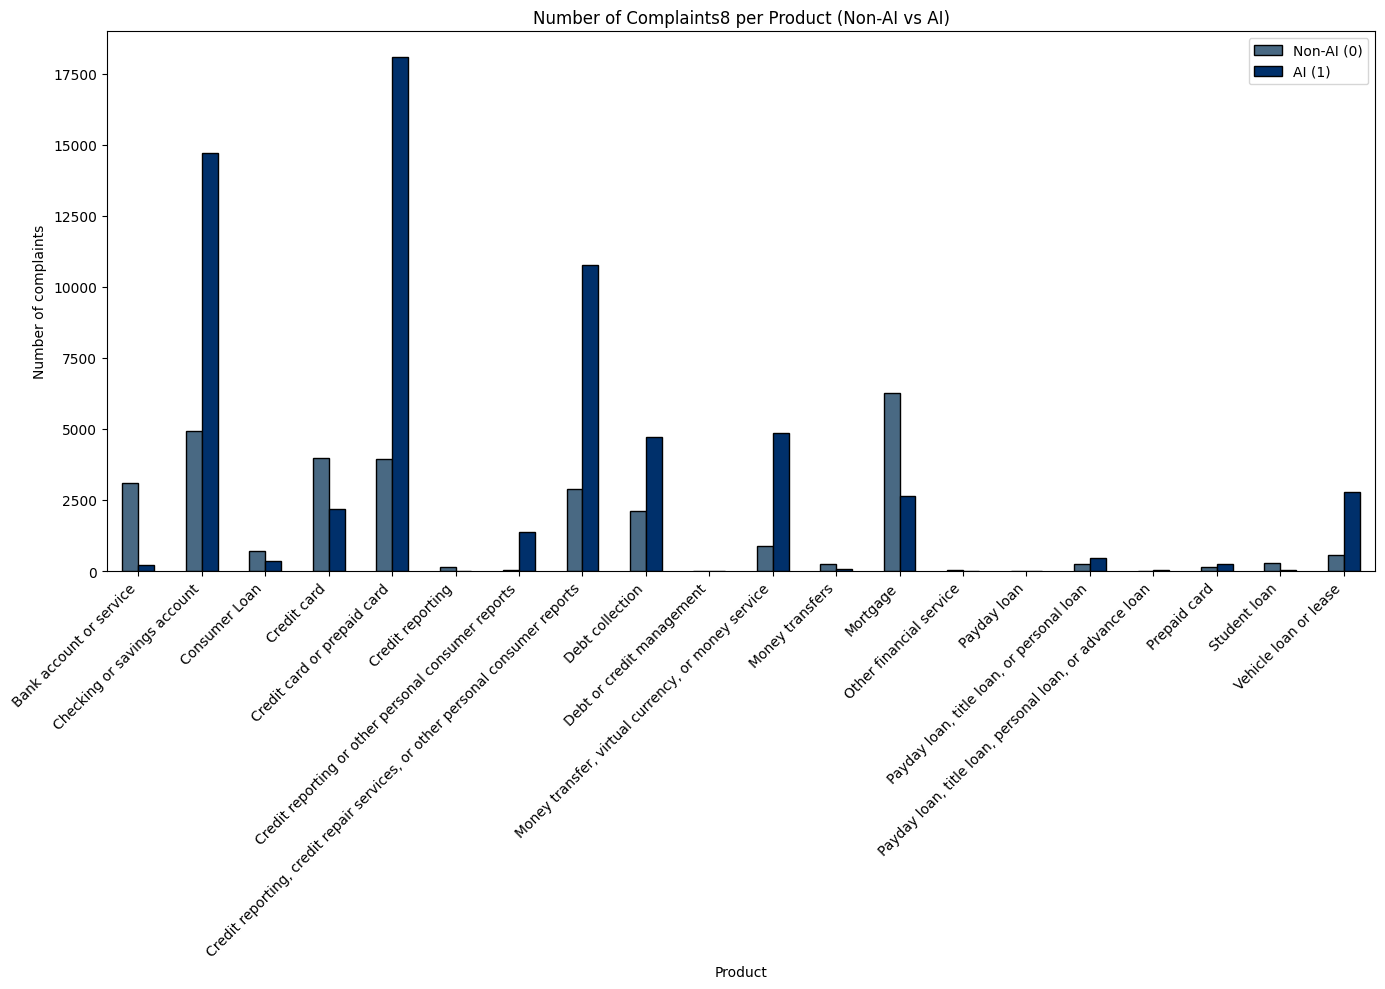

In [ ]:

# 3. Plot

plt.figure(figsize=(12,6))
colors = ['#496983', '#00306B']   # non AI, AI

prod_pivot.plot(
    kind='bar',
    color=colors,
    figsize=(14,10),
    edgecolor='black'
)

plt.title("Number of Complaints8 per Product (Non-AI vs AI)")
plt.ylabel("Number of complaints")
plt.xlabel("Product")
plt.xticks(rotation=45, ha='right')
plt.legend(["Non-AI (0)", "AI (1)"])
plt.tight_layout()
plt.show()


In [ ]:
df_share = banks_AIbot[banks_AIbot['AI_dummy'].isin(['0','1'])].copy()
df_share['AI_dummy'] = df_share['AI_dummy'].astype(int)

#2. Count complaints per Product × AI_dummy
counts = (
    df_share.groupby(['Product', 'AI_dummy'])['Complaint ID']
    .count()
    .reset_index()
)

# Pivot to wide format
pivot_counts = (
    counts.pivot(index='Product', columns='AI_dummy', values='Complaint ID')
    .fillna(0)
    .astype(int)
)

pivot_counts.columns = ['NonAI', 'AI']

# 3. Compute shares
pivot_counts['Total'] = pivot_counts['NonAI'] + pivot_counts['AI']
pivot_counts['Share_NonAI'] = pivot_counts['NonAI'] / pivot_counts['Total']
pivot_counts['Share_AI'] = pivot_counts['AI'] / pivot_counts['Total']

# Keep only the shares
share_df = pivot_counts[['Share_NonAI', 'Share_AI']]

print(share_df)

                                                    Share_NonAI  Share_AI
Product                                                                  
Bank account or service                                0.940375  0.059625
Checking or savings account                            0.251007  0.748993
Consumer Loan                                          0.676333  0.323667
Credit card                                            0.643193  0.356807
Credit card or prepaid card                            0.178957  0.821043
Credit reporting                                       0.871622  0.128378
Credit reporting or other personal consumer rep...     0.015141  0.984859
Credit reporting, credit repair services, or ot...     0.212219  0.787781
Debt collection                                        0.307986  0.692014
Debt or credit management                              0.062500  0.937500
Money transfer, virtual currency, or money service     0.154853  0.845147
Money transfers                       

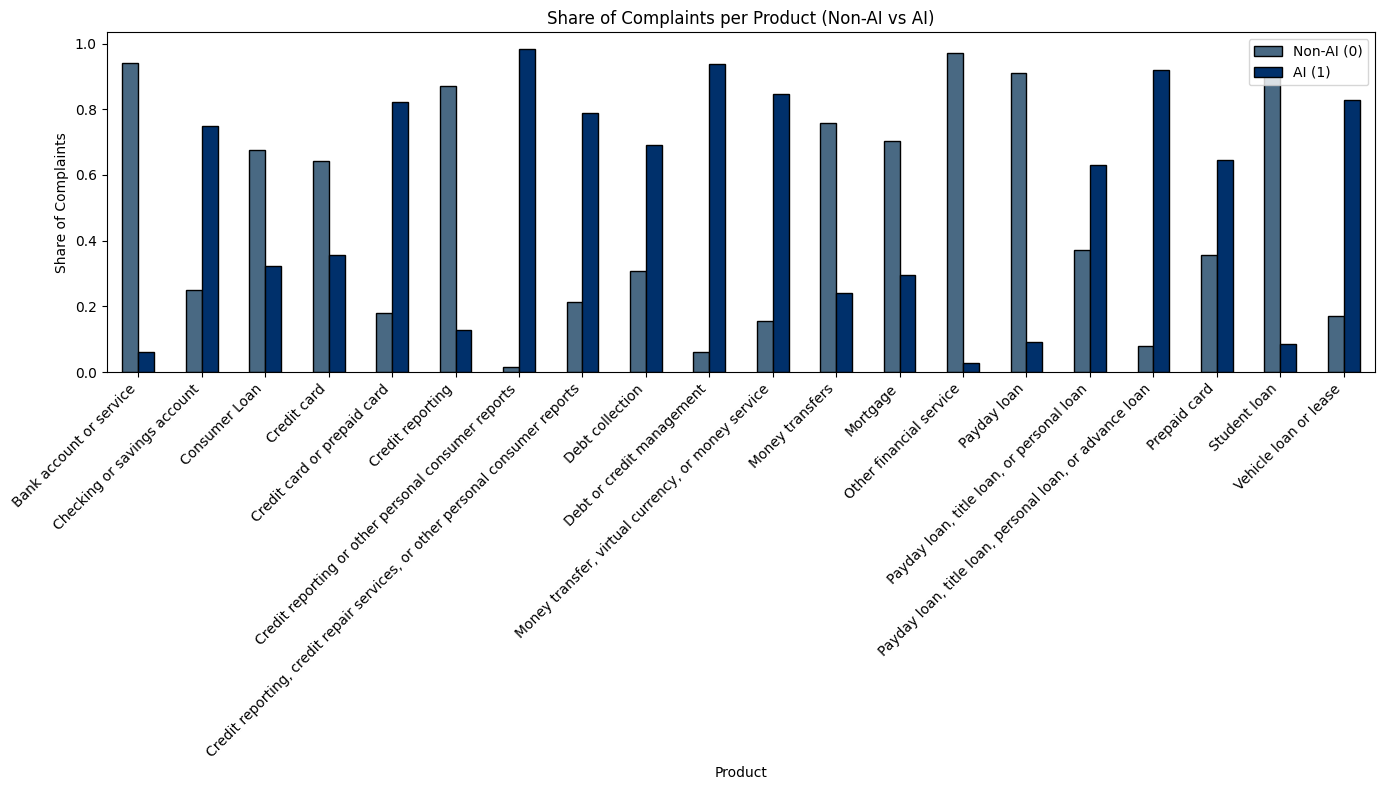

In [ ]:
# 4. Plot shares
colors = ['#496983', '#00306B']  # NonAI, AI

share_df.plot(
    kind='bar',
    figsize=(14,8),
    color=colors,
    edgecolor='black'
)

plt.title("Share of Complaints per Product (Non-AI vs AI)")
plt.ylabel("Share of Complaints")
plt.xlabel("Product")
plt.xticks(rotation=45, ha='right')
plt.legend(["Non-AI (0)", "AI (1)"])
plt.tight_layout()
plt.show()

In [ ]:
#correlation %black and median income
banks_AIbot[['MEDIAN INCOME GENERAL', 'PERCENTAGE BLACK']].corr()

,MEDIAN INCOME GENERAL,PERCENTAGE BLACK
MEDIAN INCOME GENERAL,1.000000,-0.374894
PERCENTAGE BLACK,-0.374894,1.000000


In [ ]:
#VIF scores
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df_R3[['median_income','pct_black','pct_hispanic','pct_asian']]
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)


        Variable       VIF
0  median_income  2.720566
1      pct_black  1.354060
2   pct_hispanic  1.555881
3      pct_asian  1.921812


Variance Inflation Factors for the key demographic variables are all below 3 (median income = 2.72; %Black = 1.35; %Hispanic = 1.56; %Asian = 1.92), indicating that multicollinearity is not a concern. The income and racial composition variables provide distinct explanatory information, and the estimated heterogeneity patterns are robust.

In [ ]:
banks_AIbot[['MEDIAN INCOME GENERAL', 'PERCENTAGE HOUSEHOLDER 15-24 YO', 'MEDIAN INCOME HOUSEHOLDER 15-24 YO',
       'PERCENTAGE HOUSEHOLDER 25-44 YO', 'MEDIAN INCOME HOUSEHOLDER 25-44 YO',
       'PERCENTAGE HOUSEHOLDER 45-64 YO', 'MEDIAN INCOME HOUSEHOLDER 45-64 YO',
       'PERCENTAGE HOUSEHOLDER 65+ YO', 'MEDIAN INCOME HOUSEHOLDER 65+ YO']].corr()

,MEDIAN INCOME GENERAL,PERCENTAGE HOUSEHOLDER 15-24 YO,MEDIAN INCOME HOUSEHOLDER 15-24 YO,PERCENTAGE HOUSEHOLDER 25-44 YO,MEDIAN INCOME HOUSEHOLDER 25-44 YO,PERCENTAGE HOUSEHOLDER 45-64 YO,MEDIAN INCOME HOUSEHOLDER 45-64 YO,PERCENTAGE HOUSEHOLDER 65+ YO,MEDIAN INCOME HOUSEHOLDER 65+ YO
MEDIAN INCOME GENERAL,1.000000,-0.300397,0.587812,-0.035679,0.953831,0.250136,0.955667,-0.020330,0.824340
PERCENTAGE HOUSEHOLDER 15-24 YO,-0.300397,1.000000,-0.296160,0.257443,-0.263492,-0.585327,-0.223392,-0.282885,-0.134705
MEDIAN INCOME HOUSEHOLDER 15-24 YO,0.587812,-0.296160,1.000000,0.051307,0.585113,0.122388,0.496752,-0.001638,0.396935
PERCENTAGE HOUSEHOLDER 25-44 YO,-0.035679,0.257443,0.051307,1.000000,-0.022007,-0.499845,-0.109972,-0.805481,-0.159289
MEDIAN INCOME HOUSEHOLDER 25-44 YO,0.953831,-0.263492,0.585113,-0.022007,1.000000,0.149455,0.882404,0.029582,0.701679
PERCENTAGE HOUSEHOLDER 45-64 YO,0.250136,-0.585327,0.122388,-0.499845,0.149455,1.000000,0.229950,0.013198,0.204794
MEDIAN INCOME HOUSEHOLDER 45-64 YO,0.955667,-0.223392,0.496752,-0.109972,0.882404,0.229950,1.000000,0.040425,0.838059
PERCENTAGE HOUSEHOLDER 65+ YO,-0.020330,-0.282885,-0.001638,-0.805481,0.029582,0.013198,0.040425,1.000000,0.071813
MEDIAN INCOME HOUSEHOLDER 65+ YO,0.824340,-0.134705,0.396935,-0.159289,0.701679,0.204794,0.838059,0.071813,1.000000


In [ ]:
banks_AIbot.columns

Index(['Unnamed: 0', 'Date received', 'Product', 'Sub-product', 'Issue',
       'Sub-issue', 'Consumer complaint narrative', 'Company public response',
       'Company', 'State', 'zip', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?', 'Consumer disputed?', 'Complaint ID', 'Year',
       'GEOGRAPHY', 'ZIP CODE', 'NUMBER OF HOUSEHOLDS',
       'MEDIAN INCOME GENERAL', 'PERCENTAGE WHITE', 'MEDIAN INCOME WHITE',
       'PERCENTAGE BLACK', 'MEDIAN INCOME BLACK', 'PERCENTAGE NATIVE AMERICAN',
       'MEDIAN INCOME NATIVE AMERICAN', 'PERCENTAGE ASIAN',
       'MEDIAN INCOME ASIAN', 'PERCENTAGE HAWAIIAN', 'MEDIAN INCOME HAWAIIAN',
       'PERCENTAGE OTHER RACE', 'MEDIAN INCOME OTHER RACE',
       'PERCENTAGE 2 OR MORE RACES', 'MEDIAN INCOME 2 OR MORE RACES',
       'PERCENTAGE HISPANIC/LATINO ORIGIN (OF ANY RACE)',
       'MEDIAN INCOME HISPANIC/LATINO ORIGIN (OF ANY RACE)',
       'PERCENTAGE WHITE

## **Plot US map with emotion intensity score per state**

In [ ]:
import plotly.express as px

# Make a copy
df = banks_AIbot.copy()

# Keep only rows with sentiment scores + valid states
df = df.dropna(subset=['emo_final', 'State']).copy()

# Compute average emotional intensity per state
state_avg = (
    df.groupby('State')['emo_final']
      .mean()
      .reset_index(name='avg_emo')
)

# Plot choropleth map
fig = px.choropleth(
    state_avg,
    locations="State",
    locationmode="USA-states",
    color="avg_emo",
    color_continuous_scale="Blues",
    scope="usa",
    labels={"avg_emo": "Avg Emotional Intensity"},
    title="Average Emotional Intensity by State"
)

fig.update_layout(
    title_x=0.5,
    geo=dict(bgcolor='rgba(0,0,0,0)')
)

fig.show()
